01_data_preparation

02_feature_extraction_and_ml_traning

03_acoustic_DL

04_linguistic_DL

05_image_DL

# Check CPU/GPU/Memory

In [1]:
# In order to use a GPU with this notebook, select the Runtime > Change runtime type menu and then set the hardware accelerator
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sat Jun 20 20:57:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   34C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# If the execution result of running the code cell below is 'Not using a high-RAM runtime',
# then we can enable a high-RAM runtime via Runtime > Change runtime type in the menu.
# Then select High-RAM in the Runtime shape toggle button

import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 56.9 gigabytes of available RAM

You are using a high-RAM runtime!


# Imports

In [3]:
!pip install google-cloud-storage pydub librosa matplotlib scikit-learn transformers torch captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 14.5 MB/s eta 0:00:00


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.preprocessing import label_binarize
from transformers import EarlyStoppingCallback


# Configurations

In [ ]:
import os
os.environ["HF_TOKEN"] = HFTOKEN # token from the config cell

In [ ]:
from google.colab import auth
auth.authenticate_user()

# To find the credentials automatically
from google.cloud import storage
client = storage.Client(project=GCP_PROJECT_ID) # GCP Project ID


In [ ]:
# Initialize GCP Storage
client = storage.Client()
bucket_name = VOICE_DATA_BUCKET_NAME # GCP Storage bucket name
bucket = client.get_bucket(bucket_name)
print(f"Bucket {bucket.name} successfully loaded.")

Bucket voicedata-bucket successfully loaded.


In [8]:

print(os.getcwd())

/content


In [9]:
# Configuration
AUDIO_DIR_ADD = "local_data/ADDReSS2021/processed_audio"
AUDIO_DIR_WLS = "local_data/WLS/processed_audio"
CATEGORIES = ['CN', 'AD']

# Ensure local directories exist for processing
os.makedirs("local_data/ADDReSS2021/processed_audio/", exist_ok=True)
os.makedirs("local_data/WLS/processed_audio/", exist_ok=True)
os.makedirs("local_data/processed/", exist_ok=True)

# Download the processed data from GCP

In [10]:
# Download the final ADDReSSo & WLS Transcripts CSV
print("Downloading processed transcripts...")
bucket.blob("ADDReSS2021/processed/final_transcripts.csv").download_to_filename("local_data/processed/final_transcripts.csv")
bucket.blob("WLS/processed/final_transcripts.csv").download_to_filename("local_data/processed/wls_transcripts.csv")

df = pd.read_csv("local_data/processed/final_transcripts.csv")
df_wls = pd.read_csv("local_data/processed/wls_transcripts.csv")

display(df.head())

,participant_id,audio_path,transcript,label,label_numeric
0,adrso054,local_data/processed_audio/adrso054_par.wav,I'm gonna keep burying the meal. I'm gonna hav...,AD,1
1,adrso007,local_data/processed_audio/adrso007_par.wav,Our mother standing by the sink kind of looks ...,CN,0
2,adrso128,local_data/processed_audio/adrso128_par.wav,"Um, Cookie John, and he's stepping on us, well...",AD,1
3,adrso309,local_data/processed_audio/adrso309_par.wav,"Mother is, um, drying the dishes, looking out ...",CN,0
4,adrso274,local_data/processed_audio/adrso274_par.wav,"Alright, the boy is taking a cookie out of the...",CN,0


In [11]:
# Download the final ADDReSSo & WLS audio files
print("Downloading processed audio files...")

# Ensure the DataFrames point to the correct separated folders
df['audio_path'] = df['audio_path'].str.replace('local_data/processed_audio/', 'local_data/ADDReSS2021/processed_audio/')
df_wls['audio_path'] = df_wls['audio_path'].str.replace('local_data/processed_audio/', 'local_data/WLS/processed_audio/')

# Download ADDReSSo Audio
print("Downloading ADDReSSo audio from GCS...")
addresso_download_count = 0
for blob in bucket.list_blobs(prefix="ADDReSS2021/processed/audio/"):
    if blob.name.endswith(".wav"):
        local_path = f"local_data/ADDReSS2021/processed_audio/{os.path.basename(blob.name)}"
        if not os.path.exists(local_path):
            blob.download_to_filename(local_path)
        addresso_download_count += 1

print(f"Verified/Downloaded {addresso_download_count} ADDReSSo audio files locally.")

# Download WLS Audio
print("\nDownloading WLS audio from GCS...")
wls_download_count = 0
for blob in bucket.list_blobs(prefix="WLS/processed/audio/"):
    if blob.name.endswith(".wav"):
        local_path = f"local_data/WLS/processed_audio/{os.path.basename(blob.name)}"
        if not os.path.exists(local_path):
            blob.download_to_filename(local_path)
        wls_download_count += 1

print(f"Verified/Downloaded {wls_download_count} WLS audio files locally.")

Verified/Downloaded 161 ADDReSSo audio files locally.

Verified/Downloaded 40 WLS audio files locally.


# Data Cleaning

In [12]:
import librosa

def clean_audio_dataset(df, audio_dir, target_sr=16000):
    """
    Validates audio files to ensure they exist, aren't empty,
    and can be loaded by librosa without errors.
    """
    print(f"Original dataset size: {len(df)}")
    valid_rows = []

    for idx, row in df.iterrows():
        # Extract filename to match local directory structure
        filename = os.path.basename(row['audio_path'])
        file_path = os.path.join(audio_dir, filename)

        # 1. Check if file exists and has a file size > 0 bytes
        if not os.path.exists(file_path) or os.path.getsize(file_path) == 0:
            print(f"Filtered: {filename} (Missing or 0 bytes)")
            continue

        # 2. Check if librosa can load it and duration > 0
        try:
            # We use sr=16000 as Wav2Vec2 and HuBERT expect 16kHz
            speech_array, sr = librosa.load(file_path, sr=target_sr)
            if len(speech_array) == 0:
                print(f"Filtered: {filename} (0 duration after loading)")
                continue
        except Exception as e:
            print(f"Filtered: {filename} (Corrupted/Load Error: {e})")
            continue

        valid_rows.append(row)

    cleaned_df = pd.DataFrame(valid_rows)
    print(f"Cleaned dataset size: {len(cleaned_df)}")
    return cleaned_df

# Run the cleaning function
print("Cleaning ADDReSSo:")
df_cleaned = clean_audio_dataset(df, AUDIO_DIR_ADD)
print("\nCleaning WLS:")
df_wls_cleaned = clean_audio_dataset(df_wls, AUDIO_DIR_WLS)



Cleaning ADDReSSo:
Original dataset size: 161
Cleaned dataset size: 161

Cleaning WLS:
Original dataset size: 40
Cleaned dataset size: 40


In [13]:
print("\nADDReSSo class distribution:")
print(df_cleaned['label'].value_counts().to_string())

print("\nWLS class distribution:")
print(df_wls_cleaned['label'].value_counts().to_string())


ADDReSSo class distribution:
label
AD    87
CN    74

WLS class distribution:
label
CN    20
AD    20


# The Train/Test Split

In [14]:
print(" Data Splitting ")
# Explicitly shuffle
df_cleaned = df_cleaned.sample(frac=1, random_state=42).reset_index(drop=True)

X_addresso = df_cleaned[['participant_id', 'audio_path']]
y_addresso = df_cleaned['label']

# 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_addresso, y_addresso, test_size=0.30, stratify=y_addresso, random_state=42
)

# 15% Validation, 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# WLS External
X_wls = df_wls_cleaned[['participant_id', 'audio_path']]
y_wls = df_wls_cleaned['label']

print(f"ADDReSSo Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"WLS External:   {len(X_wls)}")

 Data Splitting 
ADDReSSo Train: 112 | Val: 24 | Test: 25
WLS External:   40


# Voice / Acoustic Model Training

## 1. HuBERT

Pipeline: Audio => WavLM => CLS Embedding => Classification Head

Frameworks: PyTorch, Transformers

HuBERT inherently understands acoustic structures without manual feature engineering.

In [15]:
# from transformers import AutoProcessor
# from transformers import Wav2Vec2FeatureExtractor, HubertModel
from transformers import AutoFeatureExtractor, HubertForSequenceClassification
import torch
from torch.utils.data import Dataset
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [16]:
# 1. Force HuggingFace to use the mapping
label2id = {'CN': 0, 'AD': 1}
id2label = {0: 'CN', 1: 'AD'}

In [ ]:
# LOAD HuBERT from Huggingface

# Use the feature extractor, not the AutoProcessor
processor = AutoFeatureExtractor.from_pretrained("facebook/hubert-base-ls960")

# audio_model = HubertForSequenceClassification.from_pretrained(
#     "facebook/hubert-base-ls960",
#     num_labels=2,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True
# )

# Initialize the HuBERT model
audio_model = HubertForSequenceClassification.from_pretrained(
    "facebook/hubert-base-ls960",
    num_labels=2,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
    hidden_dropout=0.2,       # Increase from default
    attention_dropout=0.2,    # Increase from default
    feat_proj_dropout=0.2,    # Specific to the feature extractor
    final_dropout=0.2         # Dropout on the final classification head
)


The Technical Challenge.

- The audio files are 2-3 minutes long.
- If we simply increase max_length to 3 minutes (which at 16kHz is ~2.88 million samples), the model will encounter two problems:

    - VRAM Limits: The self-attention mechanism in transformers has a quadratic memory cost $O(n^2)$. Storing the attention maps for 3 minutes of audio will instantly crash even the largest A100 GPUs.
    - Positional Encoding: The pre-trained weights in the base models are not designed to handle sequences that long.

Therefore we are going for 2 options.

##1.1. Segment-Level Aggregation (The "Majority Vote" Approach)

- Instead of forcing one massive audio file, we will break the file into 30-second segments.

- Training: The model learns to classify segments.

- Inference/Evaluation: Aggregate predictions across all segments of a single patient.

In [18]:
# To force HuBERT to understand CN=0 and AD=1, we must update the PyTorch Dataset class and the model initialization.

class SegmentedDementiaDataset(Dataset):
    def __init__(self, X, y, processor, target_sr=16000, segment_length=30):
        self.X = X.reset_index(drop=True)
        self.y = y.reset_index(drop=True)
        self.processor = processor
        self.target_sr = target_sr
        self.segment_samples = target_sr * segment_length
        # EXPLICIT MAPPING HERE
        self.label2id = label2id

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        file_path = self.X.iloc[idx]['audio_path']
        speech_array, _ = librosa.load(file_path, sr=self.target_sr)

        if len(speech_array) > self.segment_samples:
            start = np.random.randint(0, len(speech_array) - self.segment_samples)
            speech_array = speech_array[start : start + self.segment_samples]

        inputs = self.processor(
            speech_array, sampling_rate=self.target_sr, return_tensors="pt",
            padding="max_length", truncation=True, max_length=self.segment_samples
        )

        label_id = self.label2id[self.y.iloc[idx]]
        return {
            'input_values': inputs['input_values'].squeeze(0),
            'labels': torch.tensor(label_id, dtype=torch.long)
        }

In [19]:
# 2. Prepare Datasets using the segmenting logic
print("Preparing PyTorch Datasets...")
train_dataset = SegmentedDementiaDataset(X_train, y_train, processor)
val_dataset = SegmentedDementiaDataset(X_val, y_val, processor)
test_dataset = SegmentedDementiaDataset(X_test, y_test, processor)

Preparing PyTorch Datasets...


Model Training

In [20]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# 3. Define Evaluation Metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Get the predicted class (0 or 1)
    predictions = np.argmax(logits, axis=-1)

    # Get probabilities for the positive class (column 1)
    # Applying softmax to convert logits to probabilities
    # We use torch.nn.functional.softmax because logits are raw, unnormalized scores.
    # roc_auc_score requires probabilities (values between 0 and 1), which softmax provides.
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

    # Calculate metrics
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')
    precision = precision_score(labels, predictions, average='binary')
    recall = recall_score(labels, predictions, average='binary')
    auc = roc_auc_score(labels, probs)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "auc": auc
    }


In [21]:
# 4. Configure Training Arguments
# Tuned for standard Colab GPU limits (batch size of 4 with gradient accumulation)
training_args = TrainingArguments(
    output_dir="./hubert_dementia_results",
    eval_strategy="epoch",  # Updated from evaluation_strategy for newer HF versions
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    num_train_epochs=40,
    weight_decay=0.01,     # L2 regularization
    warmup_ratio=0.1,      # Warmup period for learning rate
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none" # Prevents WandB integration prompts
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [22]:
# 5. Initialize Trainer
trainer = Trainer(
    model=audio_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    # Early stopping with patience of 5 epochs
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)


In [23]:
# 6. Execute Training
print("Starting HuBERT training...")
trainer.train()


Starting HuBERT training...


model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Auc
1,1.375775,0.685195,0.541667,0.702703,0.541667,1.000000,0.643357
2,1.368917,0.681818,0.541667,0.702703,0.541667,1.000000,0.622378
3,1.369400,0.661270,0.666667,0.750000,0.631579,0.923077,0.685315
4,1.311520,0.647730,0.625000,0.640000,0.666667,0.615385,0.678322
5,1.231559,0.645899,0.541667,0.521739,0.600000,0.461538,0.692308
6,1.175980,0.627460,0.625000,0.571429,0.750000,0.461538,0.734266
7,0.939833,0.633071,0.708333,0.720000,0.750000,0.692308,0.699301
8,1.040107,0.470021,0.833333,0.833333,0.909091,0.769231,0.825175
9,1.101059,0.820882,0.583333,0.444444,0.800000,0.307692,0.678322
10,0.997048,0.758026,0.541667,0.560000,0.583333,0.538462,0.678322


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=182, training_loss=1.1233122666458508, metrics={'train_runtime': 419.3248, 'train_samples_per_second': 10.684, 'train_steps_per_second': 1.335, 'total_flos': 3.965546737152e+17, 'train_loss': 1.1233122666458508, 'epoch': 13.0})

In [24]:
# 7. Final Evaluation
print("\nEvaluating on Test Set...")
eval_results = trainer.evaluate()
print(f"Final Test Results: {eval_results}")


Evaluating on Test Set...


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall,Auc
0.976919,0.746521,13,0.625000,0.608696,0.700000,0.538462,0.636364


Final Test Results: {'eval_loss': 0.7465214729309082, 'eval_accuracy': 0.625, 'eval_f1': 0.6086956521739131, 'eval_precision': 0.7, 'eval_recall': 0.5384615384615384, 'eval_auc': 0.6363636363636364}


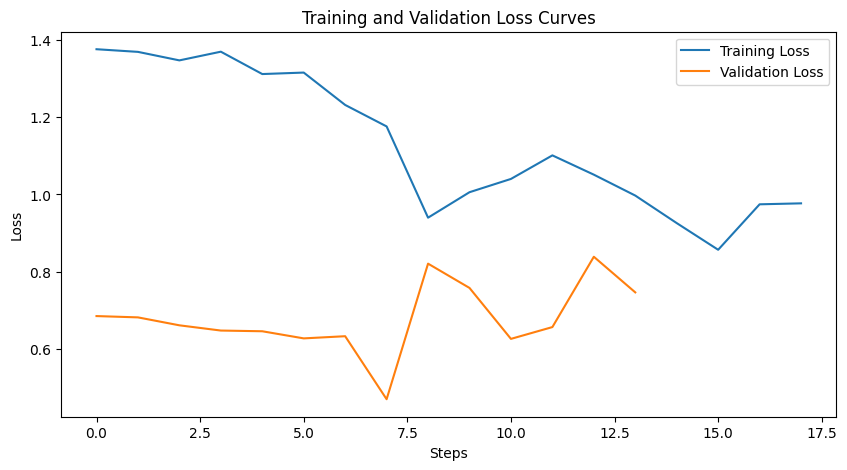

In [25]:
# Loss Curve

def plot_loss_curves(trainer):
    log_history = trainer.state.log_history

    train_loss = [x['loss'] for x in log_history if 'loss' in x]
    # Validation loss is logged at evaluation steps
    eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

    plt.figure(figsize=(10, 5))
    plt.plot(train_loss, label='Training Loss')
    plt.plot(eval_loss, label='Validation Loss')
    plt.title('Training and Validation Loss Curves')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_loss_curves(trainer)

Implement Majority Vote for Inference

In [26]:
# Core inference engine.
# It handles the "micro" level task of taking a single 2-3 minute audio file, slicing it into 30-second chunks,
# running the model on those chunks, and calculating the majority vote.
def predict_patient_level(model, processor, audio_path, segment_length=30):
    """Returns majority class prediction AND average AD probability."""
    speech_array, _ = librosa.load(audio_path, sr=16000)
    seg_samples = segment_length * 16000

    if len(speech_array) < seg_samples:
        segments = [speech_array]
    else:
        segments = [speech_array[i:i + seg_samples] for i in range(0, len(speech_array), seg_samples)]

    segment_preds = []
    segment_probs = [] # Track probabilities for ROC-AUC

    model.eval()
    for seg in segments:
        inputs = processor(seg, sampling_rate=16000, return_tensors="pt", padding=True).to(model.device)
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.nn.functional.softmax(logits, dim=-1)

            segment_preds.append(torch.argmax(logits, dim=-1).item())
            segment_probs.append(probs[0, 1].item()) # Index 1 is AD

    final_pred = max(set(segment_preds), key=segment_preds.count)
    final_prob = np.mean(segment_probs) # Average probability across segments
    return final_pred, final_prob

In [27]:
# evaluation helper

# It loops through the entire dataset (e.g. X_test), and for every single row,
    # it calls the predict_patient_level() function to get the prediction.
    # Then it calculates the aggregate metrics, AUC scores, and generates the plots.

def evaluate_model_performance(model_name, X_eval, y_eval, dataset_name, categories, model=audio_model, processor=processor):
    print(f"Running inference on {dataset_name}...")
    y_true = y_eval.values
    y_pred = []
    y_proba = []

    # 1. Inference Loop
    for idx, row in X_eval.iterrows():
        pred_id, prob_ad = predict_patient_level(model, processor, row['audio_path'])
        y_pred.append(id2label[pred_id])

        # Create a full probability distribution [Prob_CN, Prob_AD]
        # (This adapts current binary output to work with multi-class ROC calculators)
        prob_cn = 1.0 - prob_ad
        y_proba.append([prob_cn, prob_ad])

    y_proba = np.array(y_proba)

    # 2. Text Outputs
    print(f"\n{'='*60}")
    print(f"  Evaluating: {model_name} | Dataset: {dataset_name}")
    print(f"{'='*60}")

    # Overall Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"Overall Accuracy: {acc:.4f}\n")

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_true, y_pred, labels=categories, target_names=categories))

    # Sensitivity and Specificity
    print("Sensitivity and Specificity per class:")
    cm = confusion_matrix(y_true, y_pred, labels=categories)
    for i, category in enumerate(categories):
        TP = cm[i, i]
        FN = np.sum(cm[i, :]) - TP
        FP = np.sum(cm[:, i]) - TP
        TN = np.sum(cm) - (TP + FP + FN)

        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        print(f"  {category:<4} - Sensitivity: {sensitivity:.4f}, Specificity: {specificity:.4f}")

    # AUC-ROC
    print("\nAUC-ROC per class:")
    y_true_bin = label_binarize(y_true, classes=categories)

    # Handle the shape differences between binary and multi-class label_binarize arrays
    if len(categories) == 2:
        auc_0 = roc_auc_score(1 - y_true_bin, y_proba[:, 0])
        auc_1 = roc_auc_score(y_true_bin, y_proba[:, 1])
        print(f"  {categories[0]:<4} : {auc_0:.4f}")
        print(f"  {categories[1]:<4} : {auc_1:.4f}")
        macro_auc = (auc_0 + auc_1) / 2.0
        print(f"\nMacro-average AUC-ROC: {macro_auc:.4f}\n")
    else:
        aucs = []
        for i, category in enumerate(categories):
            auc = roc_auc_score(y_true_bin[:, i], y_proba[:, i])
            aucs.append(auc)
            print(f"  {category:<4} : {auc:.4f}")
        macro_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
        print(f"\nMacro-average AUC-ROC: {macro_auc:.4f}\n")

    # 3. Visualizations
    print("ROC Curve and Confusion Matrix:")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC Curve
    axes[0].set_title('ROC Curve')
    if len(categories) == 2:
        fpr0, tpr0, _ = roc_curve(1 - y_true_bin, y_proba[:, 0])
        axes[0].plot(fpr0, tpr0, lw=2, label=f'{categories[0]} (AUC = {auc_0:.4f})')

        fpr1, tpr1, _ = roc_curve(y_true_bin, y_proba[:, 1])
        axes[0].plot(fpr1, tpr1, lw=2, label=f'{categories[1]} (AUC = {auc_1:.4f})')
    else:
        for i, category in enumerate(categories):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
            axes[0].plot(fpr, tpr, lw=2, label=f'{category} (AUC = {aucs[i]:.4f})')

    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend(loc="lower right")

    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories, yticklabels=categories, ax=axes[1])
    axes[1].set_title('Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

Running inference on Training Set...

  Evaluating: HuBERT Base | Dataset: Training Set
Overall Accuracy: 0.8482

Classification Report:
              precision    recall  f1-score   support

          CN       0.78      0.92      0.85        51
          AD       0.92      0.79      0.85        61

    accuracy                           0.85       112
   macro avg       0.85      0.85      0.85       112
weighted avg       0.86      0.85      0.85       112

Sensitivity and Specificity per class:
  CN   - Sensitivity: 0.9216, Specificity: 0.7869
  AD   - Sensitivity: 0.7869, Specificity: 0.9216

AUC-ROC per class:
  CN   : 0.9245
  AD   : 0.9245

Macro-average AUC-ROC: 0.9245

ROC Curve and Confusion Matrix:


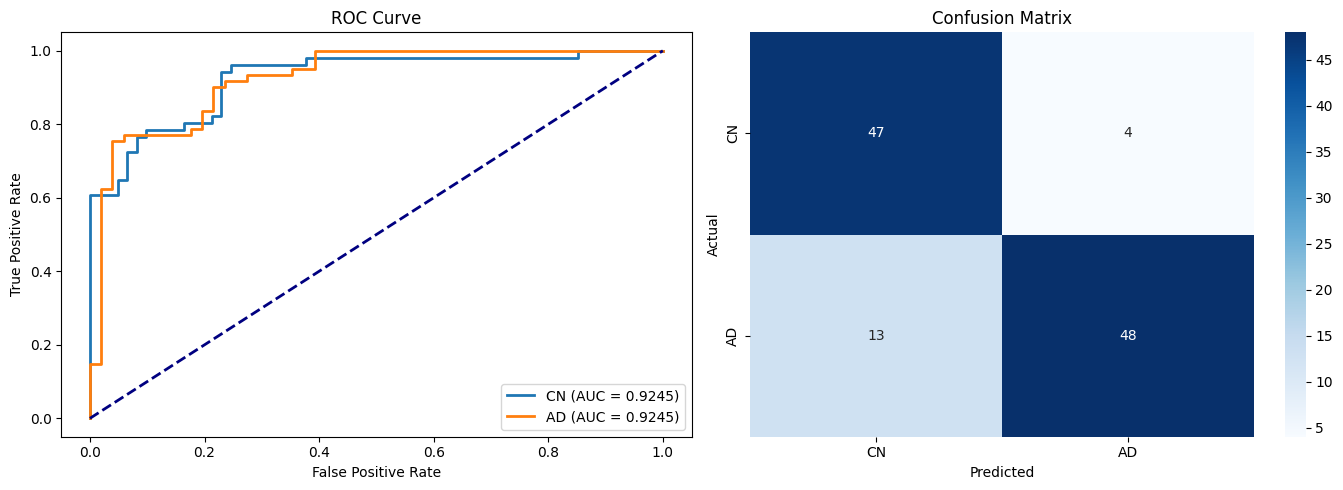

In [28]:
evaluate_model_performance("HuBERT Base", X_train, y_train, "Training Set", CATEGORIES)

Running inference on Validation Set...

  Evaluating: HuBERT Base | Dataset: Validation Set
Overall Accuracy: 0.7500

Classification Report:
              precision    recall  f1-score   support

          CN       0.65      1.00      0.79        11
          AD       1.00      0.54      0.70        13

    accuracy                           0.75        24
   macro avg       0.82      0.77      0.74        24
weighted avg       0.84      0.75      0.74        24

Sensitivity and Specificity per class:
  CN   - Sensitivity: 1.0000, Specificity: 0.5385
  AD   - Sensitivity: 0.5385, Specificity: 1.0000

AUC-ROC per class:
  CN   : 0.8951
  AD   : 0.8951

Macro-average AUC-ROC: 0.8951

ROC Curve and Confusion Matrix:


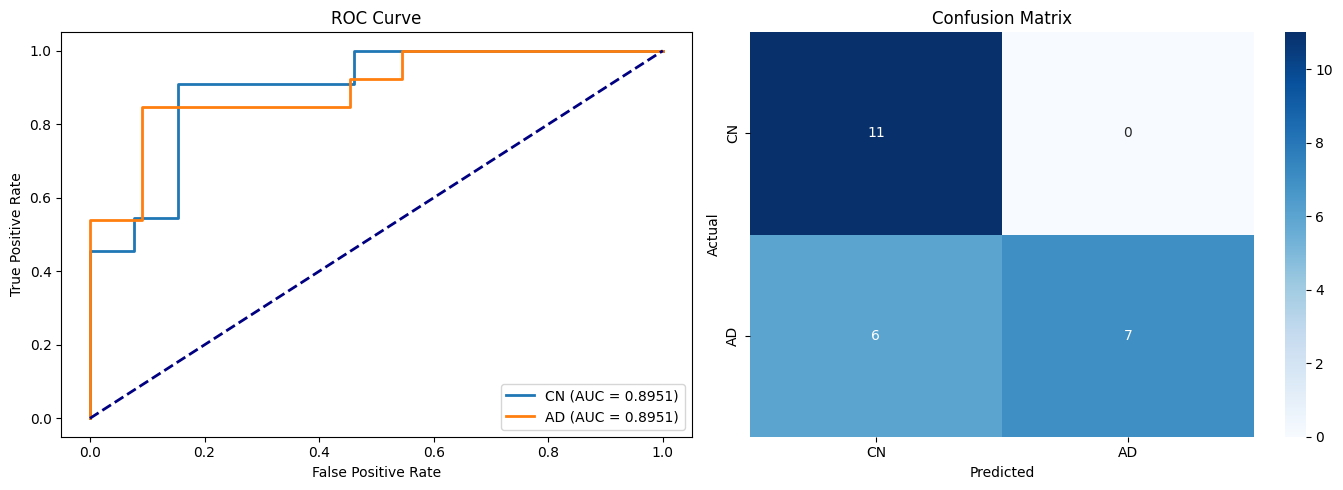

In [29]:
evaluate_model_performance("HuBERT Base", X_val, y_val, "Validation Set", CATEGORIES)

Running inference on Testing Set...

  Evaluating: HuBERT Base | Dataset: Testing Set
Overall Accuracy: 0.8400

Classification Report:
              precision    recall  f1-score   support

          CN       0.79      0.92      0.85        12
          AD       0.91      0.77      0.83        13

    accuracy                           0.84        25
   macro avg       0.85      0.84      0.84        25
weighted avg       0.85      0.84      0.84        25

Sensitivity and Specificity per class:
  CN   - Sensitivity: 0.9167, Specificity: 0.7692
  AD   - Sensitivity: 0.7692, Specificity: 0.9167

AUC-ROC per class:
  CN   : 0.8974
  AD   : 0.8974

Macro-average AUC-ROC: 0.8974

ROC Curve and Confusion Matrix:


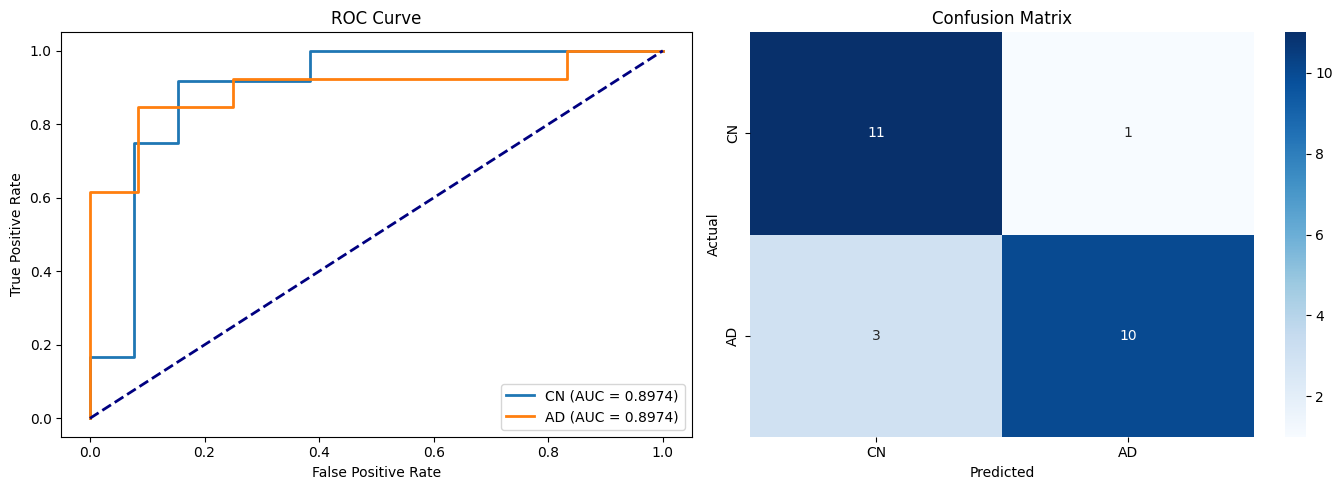

In [30]:
evaluate_model_performance("HuBERT Base", X_test, y_test, "Testing Set", CATEGORIES)

Running inference on WLS External Set...

  Evaluating: HuBERT Base | Dataset: WLS External Set
Overall Accuracy: 0.6000

Classification Report:
              precision    recall  f1-score   support

          CN       0.61      0.55      0.58        20
          AD       0.59      0.65      0.62        20

    accuracy                           0.60        40
   macro avg       0.60      0.60      0.60        40
weighted avg       0.60      0.60      0.60        40

Sensitivity and Specificity per class:
  CN   - Sensitivity: 0.5500, Specificity: 0.6500
  AD   - Sensitivity: 0.6500, Specificity: 0.5500

AUC-ROC per class:
  CN   : 0.5825
  AD   : 0.5825

Macro-average AUC-ROC: 0.5825

ROC Curve and Confusion Matrix:


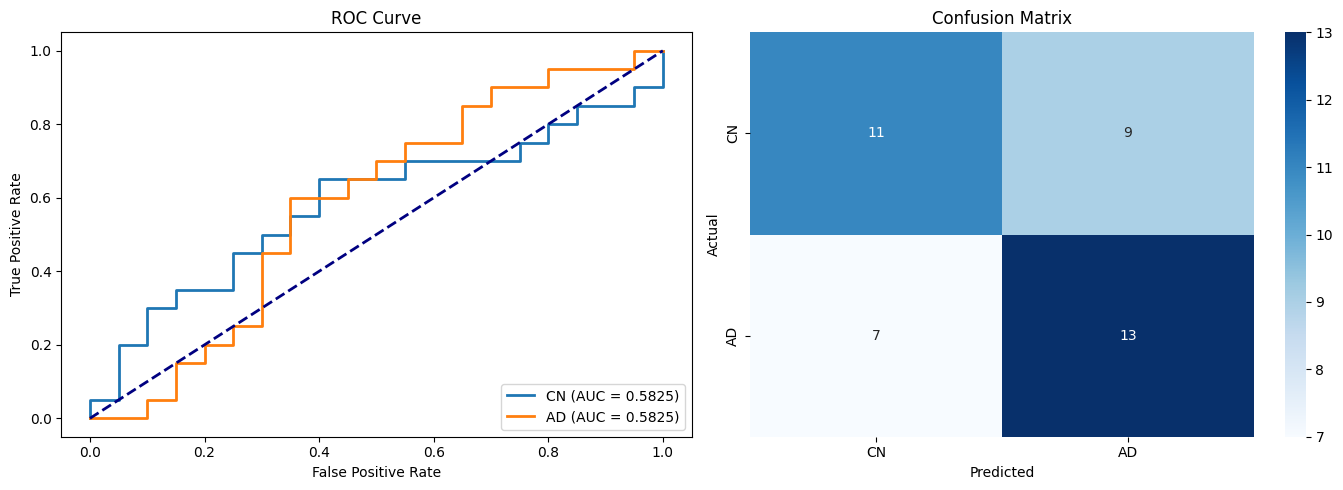

In [31]:
evaluate_model_performance("HuBERT Base", X_wls, y_wls, "WLS External Set", CATEGORIES)

In [32]:
# 1. Get the row from the test set
row_idx = 0
test_row = X_test.iloc[row_idx]
test_audio_path = test_row['audio_path']
actual_label = y_test.iloc[row_idx]

# 2. Get the prediction
# Unpack the tuple: final_pred goes to predicted_id, final_prob goes to _ (ignored)
predicted_id, predicted_prob = predict_patient_level(audio_model, processor, test_audio_path)

# 3. Create reverse mapping (id to label)
id2label = {v: k for k, v in test_dataset.label2id.items()}
predicted_label = id2label[predicted_id]

# 4. Print results
print(f"Testing on file: {test_audio_path}")
print(f"Actual Label:    {actual_label}")
print(f"Predicted Label: {predicted_label}")
print(f"Confidence (Prob): {predicted_prob:.4f}")

Testing on file: local_data/ADDReSS2021/processed_audio/adrso257_par.wav
Actual Label:    CN
Predicted Label: AD
Confidence (Prob): 0.7919


# Feature Importance

In [33]:
# Run this to see the confidence scores for the test set
predictions = trainer.predict(test_dataset)
# Apply softmax to convert logits to probabilities
probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()

# Add to the dataframe for analysis
results_df = pd.DataFrame(X_test).copy()
results_df['prob_AD'] = probs[:, 0]  # Assuming 0 is AD, 1 is CN
results_df['prob_CN'] = probs[:, 1]
results_df['pred'] = np.argmax(probs, axis=-1)

# Sort by the most "confidently wrong" predictions
results_df['is_correct'] = (results_df['pred'] == y_test.values)
print(results_df.sort_values(by='prob_AD', ascending=False).head(10))

    participant_id                                         audio_path  \
105       adrso157  local_data/ADDReSS2021/processed_audio/adrso15...   
135       adrso307  local_data/ADDReSS2021/processed_audio/adrso30...   
36        adrso262  local_data/ADDReSS2021/processed_audio/adrso26...   
71        adrso158  local_data/ADDReSS2021/processed_audio/adrso15...   
158       adrso299  local_data/ADDReSS2021/processed_audio/adrso29...   
39        adrso267  local_data/ADDReSS2021/processed_audio/adrso26...   
139       adrso223  local_data/ADDReSS2021/processed_audio/adrso22...   
142       adrso151  local_data/ADDReSS2021/processed_audio/adrso15...   
55        adrso220  local_data/ADDReSS2021/processed_audio/adrso22...   
18        adrso016  local_data/ADDReSS2021/processed_audio/adrso01...   

      prob_AD   prob_CN  pred  is_correct  
105  0.840766  0.159234     0       False  
135  0.837539  0.162461     0       False  
36   0.831564  0.168436     0       False  
71   0.828888  0.171

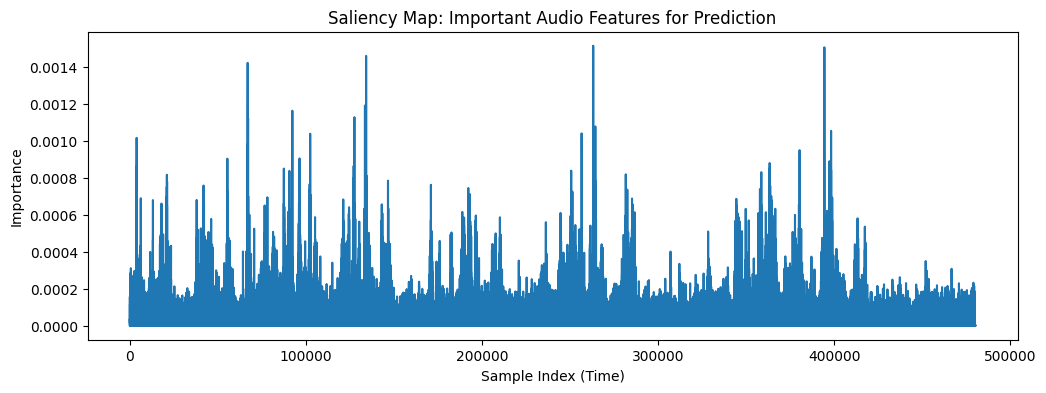

In [34]:
from captum.attr import Saliency

# 1. Get a single sample from the test set
# We use the test_dataset we defined earlier
sample = test_dataset[0]
input_values = sample['input_values'].unsqueeze(0).to(audio_model.device)

# 2. Define the explanation function
def explain_audio_prediction(model, input_values, target_class=0):
    model.eval()
    def forward_func(inputs):
        return model(input_values=inputs).logits

    saliency = Saliency(forward_func)

    # Ensure gradients are tracked for the input
    input_values.requires_grad = True
    attr = saliency.attribute(input_values, target=target_class)

    return attr.squeeze().cpu().detach().numpy()

# 3. Run the explanation
attr = explain_audio_prediction(audio_model, input_values, target_class=0)

# 4. Plot
plt.figure(figsize=(12, 4))
plt.plot(attr)
plt.title("Saliency Map: Important Audio Features for Prediction")
plt.xlabel("Sample Index (Time)")
plt.ylabel("Importance")
plt.show()

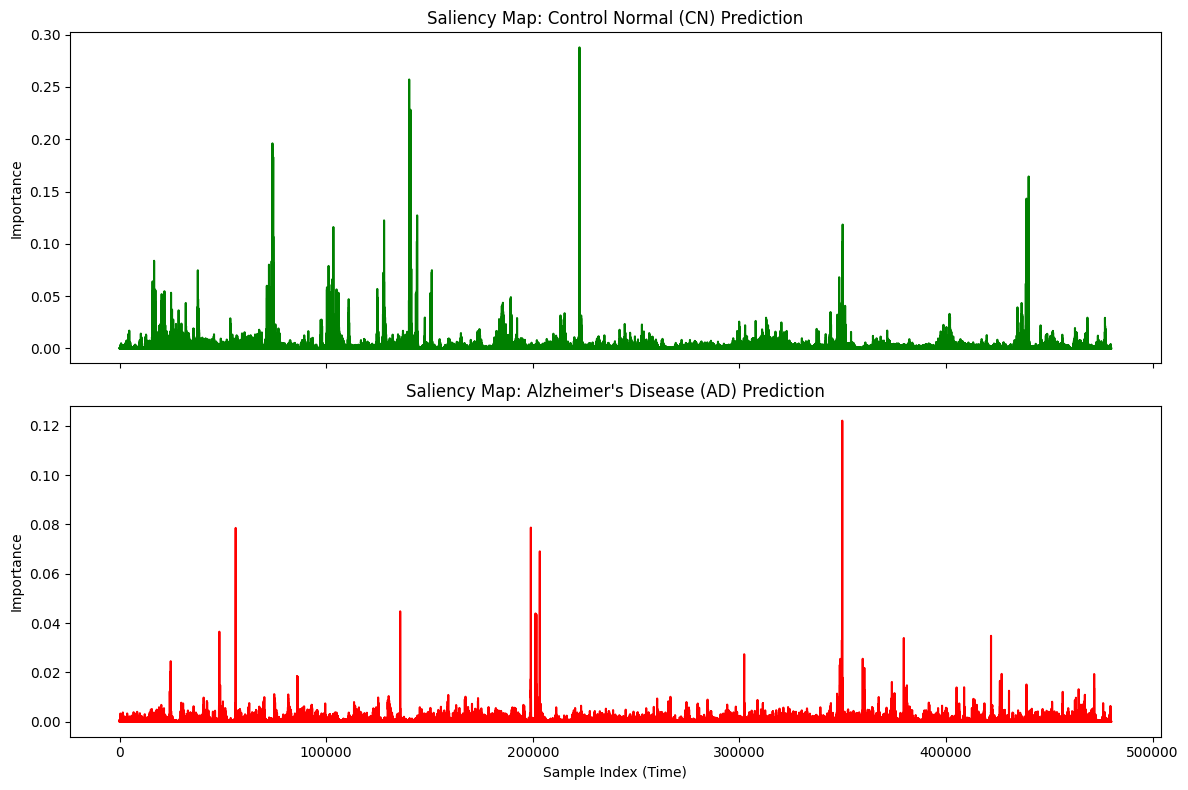

In [35]:
from captum.attr import Saliency
import matplotlib.pyplot as plt

def plot_saliency_comparison(model, test_loader):
    model.eval()
    batch = next(iter(test_loader))
    inputs = batch['input_values'].to(model.device)
    labels = batch['labels'].numpy()

    # Isolate one CN and one AD sample from the batch
    idx_cn = np.where(labels == 0)[0][0]
    idx_ad = np.where(labels == 1)[0][0]

    input_cn = inputs[idx_cn].unsqueeze(0)
    input_ad = inputs[idx_ad].unsqueeze(0)

    def forward_func(x):
        return model(input_values=x).logits

    saliency = Saliency(forward_func)

    # Calculate gradients (Target 0 for CN, 1 for AD)
    input_cn.requires_grad = True
    input_ad.requires_grad = True

    attr_cn = saliency.attribute(input_cn, target=0).squeeze().cpu().detach().numpy()
    attr_ad = saliency.attribute(input_ad, target=1).squeeze().cpu().detach().numpy()

    # Plot side-by-side
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(attr_cn, color='green')
    axes[0].set_title("Saliency Map: Control Normal (CN) Prediction")
    axes[0].set_ylabel("Importance")

    axes[1].plot(attr_ad, color='red')
    axes[1].set_title("Saliency Map: Alzheimer's Disease (AD) Prediction")
    axes[1].set_xlabel("Sample Index (Time)")
    axes[1].set_ylabel("Importance")

    plt.tight_layout()
    plt.show()

# Run the comparison
from torch.utils.data import DataLoader
test_loader_sample = DataLoader(test_dataset, batch_size=16, shuffle=True)
plot_saliency_comparison(audio_model, test_loader_sample)

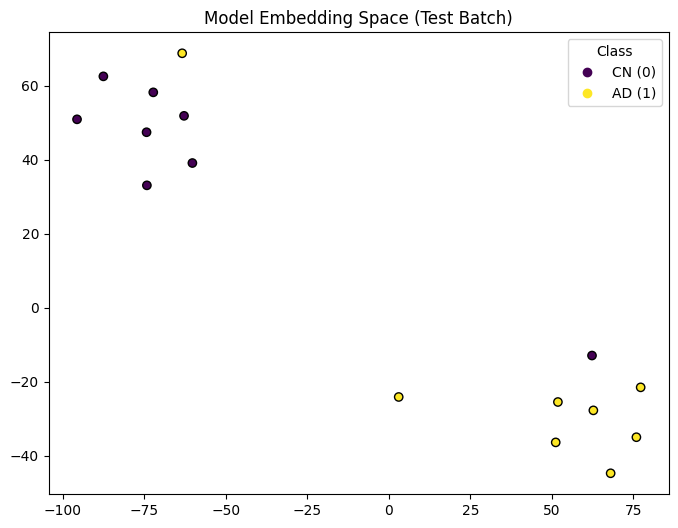

In [36]:
from sklearn.manifold import TSNE
import torch
from torch.utils.data import DataLoader

# 1. Grab a batch of data
test_loader = DataLoader(test_dataset, batch_size=16)
batch = next(iter(test_loader))
inputs = batch['input_values'].to(audio_model.device)

# 2. Extract the embeddings
with torch.no_grad():
    outputs = audio_model(input_values=inputs, output_hidden_states=True)
embeddings = outputs.hidden_states[-1][:, 0, :].cpu().detach().numpy()

# 3. Reduce to 2D
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
reduced = tsne.fit_transform(embeddings)

# 4. Plot
plt.figure(figsize=(8, 6))
labels = batch['labels'].numpy()

# Use a discrete colormap to make CN(0) and AD(1) distinct
scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='viridis', edgecolors='k')

# Create custom legend
handles, _ = scatter.legend_elements()
legend_labels = ['CN (0)', 'AD (1)']
plt.legend(handles, legend_labels, title="Class")

plt.title("Model Embedding Space (Test Batch)")
plt.show()

The points appearing in the negative region of the plot are a direct result of the t-SNE (t-Distributed Stochastic Neighbor Embedding) algorithm used (which is what generated the embedding plot)